In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)
filepath=path+"/Iris.csv"
print(filepath)

Path to dataset files: /home/cgraiff/.cache/kagglehub/datasets/uciml/iris/versions/2
/home/cgraiff/.cache/kagglehub/datasets/uciml/iris/versions/2/Iris.csv


In [27]:
with open(filepath, 'r') as f:
    df = pd.read_csv(f)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
### Exercise 1: Build a scatterplot of petal length per species
# Hint: 
species=df['Species'].unique()
print(species)

grouped = df.groupby('Species')['PetalLengthCm'].mean()
grouped = grouped.reset_index() # By default, groupby delivers a Series. This commands convert the Series to a DataFrame. 
# If you are not confident about what is being done here, you can revise the concepts of "Series" and "DataFrame" by looking at last week's notebooks.
grouped.head()


['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,Species,PetalLengthCm
0,Iris-setosa,1.464
1,Iris-versicolor,4.260
2,Iris-virginica,5.552


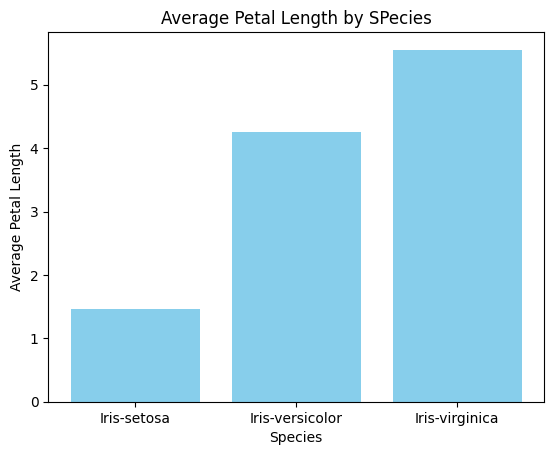

In [ ]:
# Exercise: Plot a bar plot of average petal length by species.
# Plot - Bar plot is a good choice for categorical vs numerical
plt.bar(grouped['Species'], grouped['PetalLengthCm'], color='skyblue')
plt.xlabel('Species')
plt.ylabel('Average Petal Length')
plt.title('Average Petal Length by SPecies')
plt.show()

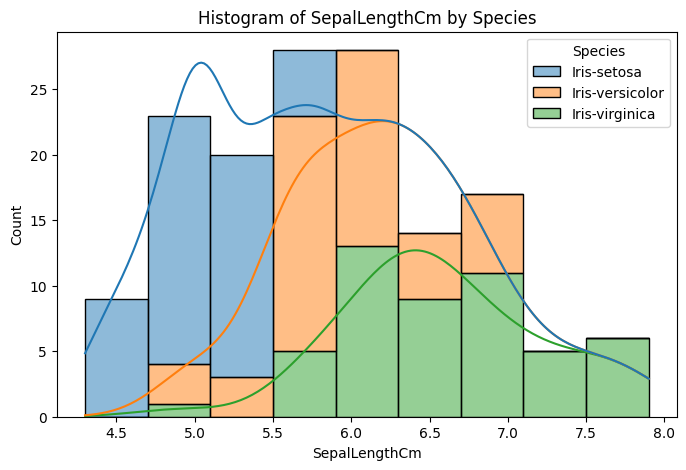

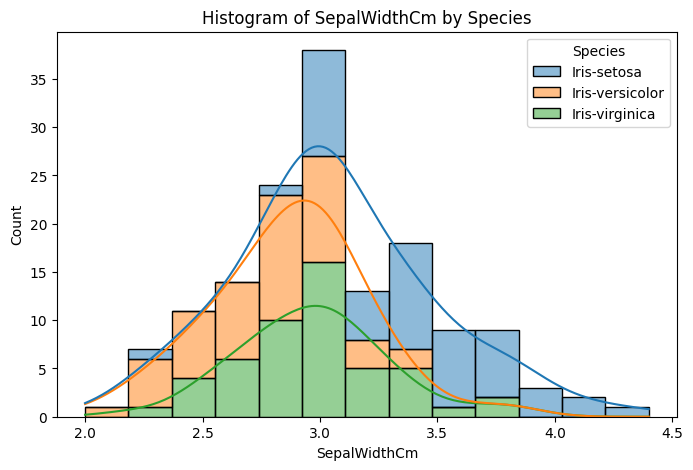

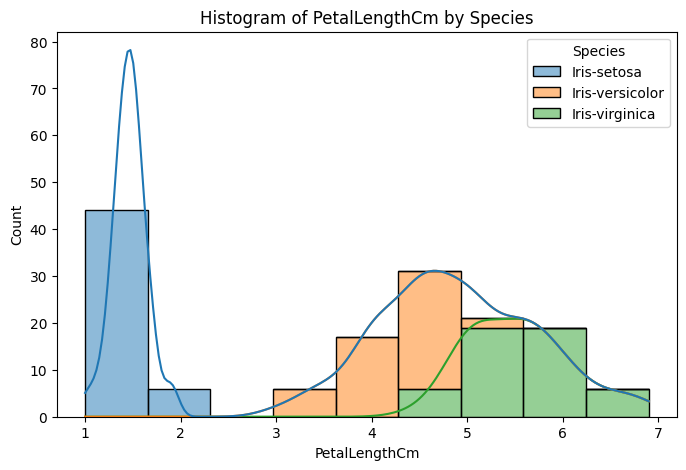

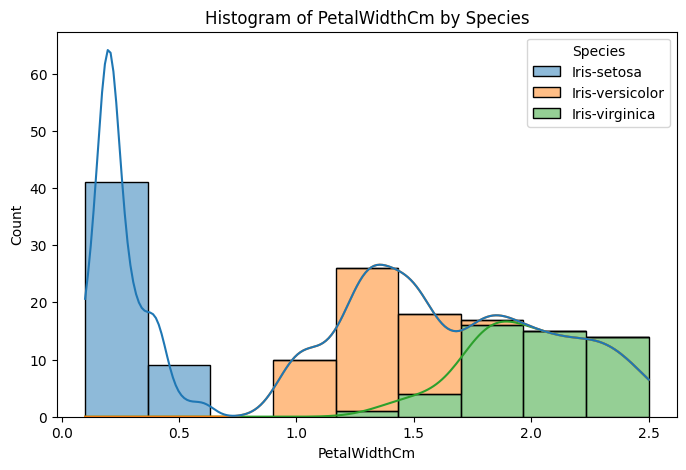

In [ ]:
# Plot histograms for all numeric features, colored by species.

numeric_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, hue='Species', multiple='stack', kde=True)
    plt.title(f'Histogram of {feature} by Species')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

/tmp/ipykernel_110542/3949888112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Species', y=feature, palette="Pastel1")


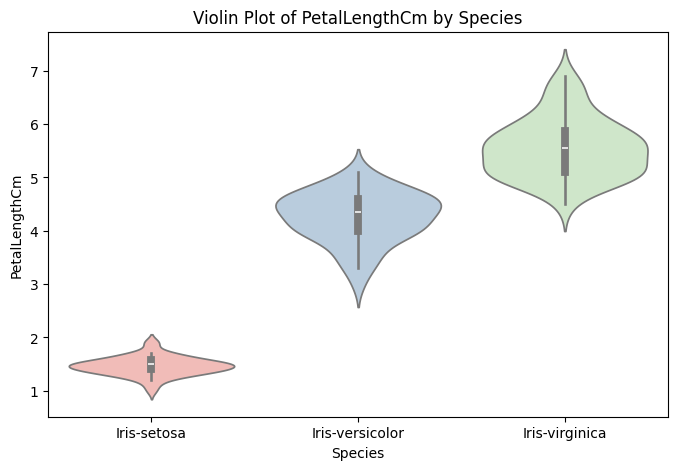

/tmp/ipykernel_110542/3949888112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Species', y=feature, palette="Pastel1")


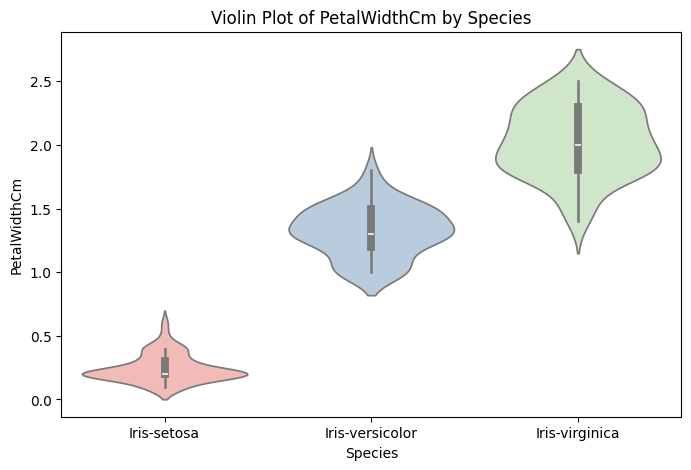

In [33]:
# Create violin plots for PetalLengthCm and PetalWidthCm by species.

for feature in ['PetalLengthCm', 'PetalWidthCm']:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x='Species', y=feature, palette="Pastel1")
    plt.title(f'Violin Plot of {feature} by Species')
    plt.show()

/tmp/ipykernel_110542/2555277261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feature, palette="Set2")


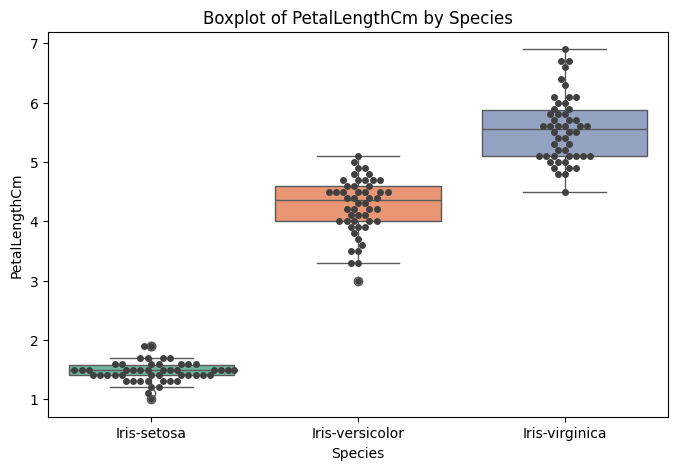

/tmp/ipykernel_110542/2555277261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feature, palette="Set2")
/home/cgraiff/miniconda3/envs/transf_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


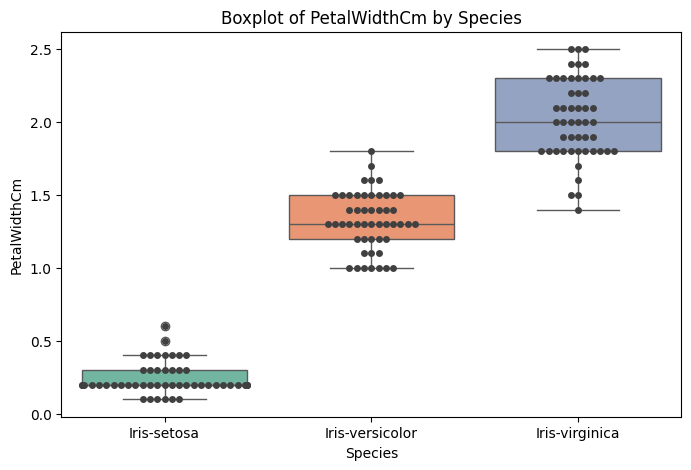

In [34]:
# Use boxplots to visualize spread and outliers.


for feature in ['PetalLengthCm', 'PetalWidthCm']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Species', y=feature, palette="Set2")
    sns.swarmplot(data=df, x='Species', y=feature, color=".25")
    plt.title(f'Boxplot of {feature} by Species')
    plt.show()

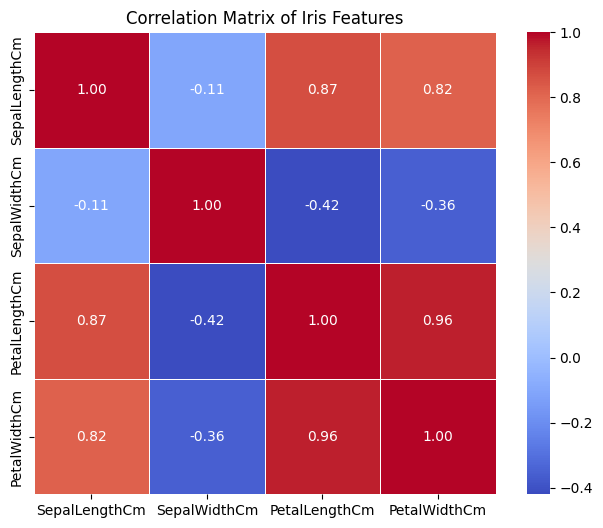

In [35]:
# Compute and visualize the correlation matrix using a heatmap.

corr_matrix = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,       # show correlation values
    cmap='coolwarm',  # color map
    fmt=".2f",        # format numbers
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix of Iris Features')
plt.show()